# Parameter learning for RockSample

In [ ]:
%%capture

try:
  import numpyro
except:
  !pip install numpyro
  import numpyro

numpyro.set_host_device_count(4)

import jax
import jax.numpy as jnp

import math
import random
import time
import tqdm
import os
import pickle

from copy import copy

import numpy as np
from scipy.special import softmax

import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, SVI, Trace_ELBO, Predictive
from numpyro.optim import Adam

from numpyro.infer import MCMC, NUTS

import matplotlib.pyplot as plt
from scipy.stats import gamma, expon, lognorm, bernoulli
import scipy.stats as stats
from scipy.stats import wasserstein_distance
from scipy.optimize import minimize_scalar
from jax.scipy.special import logsumexp

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = '/content/drive/MyDrive/thesis-pomdp-inference/'
ROCKSAMPLE_DIR = f'{BASE_DIR}rocksample/'

os.makedirs(ROCKSAMPLE_DIR, exist_ok=True)
os.makedirs(f'{ROCKSAMPLE_DIR}data/', exist_ok=True)
os.makedirs(f'{ROCKSAMPLE_DIR}inference/', exist_ok=True)
os.makedirs(f'{ROCKSAMPLE_DIR}experiments/', exist_ok=True)

print("Directories ready in Drive")
print(f"  Base: {BASE_DIR}")
print(f"  RockSample: {ROCKSAMPLE_DIR}")

Mounted at /content/drive
Directories ready in Drive
  Base: /content/drive/MyDrive/thesis-pomdp-inference/
  RockSample: /content/drive/MyDrive/thesis-pomdp-inference/rocksample/


In [ ]:
def save_data(filename, data, subdir='', show_prints=True):
    """Save data to Drive with subdirectory support"""
    save_dir = f'{ROCKSAMPLE_DIR}{subdir}/'
    os.makedirs(save_dir, exist_ok=True)

    filepath = f'{save_dir}{filename}.pkl'
    with open(filepath, 'wb') as f:
        pickle.dump(data, f)

    if show_prints:
        print(f"Saved: {filename}")

def load_data(filename, subdir='', show_prints=True):
    """Load data from Drive"""
    filepath = f'{ROCKSAMPLE_DIR}{subdir}/{filename}.pkl'
    if os.path.exists(filepath):
        with open(filepath, 'rb') as f:
            data = pickle.load(f)
        if show_prints:
            print(f"Loaded: {filename}")
        return data
    else:
        if show_prints:
            print(f"Not found: {filename}")
        return None

def file_exists(filename, subdir='', show_prints=True):
    """Check if file exists"""
    filepath = f'{ROCKSAMPLE_DIR}{subdir}/{filename}.pkl'
    file_exists = os.path.exists(filepath)
    if show_prints:
        if file_exists:
            print(f"{filename} exists")
        else:
            print(f"{filename} does not exist")
    return file_exists

## Problem definition

* A crawler moves from left to right through a grid.
* If there is a rock in a cell, the agent can sample the rock.
  * If the rock is good, the reward is positive.
  * If the rock is bad, the reward is negative.
* The crawler can sense a rock remotely, with observation noise.

## Sensing Models in POMDPs: Mathematical Formulation

### Sensing Probability Formula

The probability of correctly sensing a rock's quality at distance $d$ is given by:

$$p(d, \text{sensi}) = 0.5 + 0.5 \cdot e^{-\frac{d \cdot \ln(2)}{\text{sensi}}}$$

Where:
- $d = \sqrt{(x - x_{\text{rock}})^2 + (y - y_{\text{rock}})^2}$ is the Euclidean distance
- $\text{sensi}$ is the sensitivity parameter
- $\ln(2)$ is the natural logarithm of 2 (approximately 0.693)

### Mathematical Properties

This formula has key properties that make it suitable for POMDP sensing:

1. **Perfect accuracy at zero distance**:  
   When $d = 0$: $p(0, \text{sensi}) = 0.5 + 0.5 \cdot e^0 = 1.0$

2. **75% accuracy at distance = sensi**:  
   When $d = \text{sensi}$: $p(\text{sensi}, \text{sensi}) = 0.5 + 0.5 \cdot e^{-\ln(2)} = 0.5 + 0.5 \cdot \frac{1}{2} = 0.75$

3. **Approaches random guessing at infinite distance**:  
   As $d \to \infty$: $p(d, \text{sensi}) \to 0.5$

### Selecting Appropriate Sensitivity Values

The sensitivity parameter has a clear interpretation: it is the distance at which sensing accuracy drops to 75%.

The optimal sensitivity should create meaningful gradients of accuracy across the grid space. With a properly calibrated sensitivity parameter, the agent faces genuine uncertainty when sensing distant rocks, while having reliable information about nearby rocks.

In [ ]:
SAMPLE = 0
SENSE = 1

HEIGHT = 5
WIDTH = 5
PSUCCESS = 0.8
PSENSE = 0.75

NLOGS = 25
NROCKS = 2

In [ ]:
class Grid:
    """RockSample grid of size width x height, with rocks as (x, y, quality).
    """
    def __init__(self, width=5, height=5, rocks=[(3, 1, True), (4, 3, False)]):
        self.width = width
        self.height = height
        self.rocks = rocks

class Crawler:
    """RockSample grid with sensor sensitivity
        0.5 + 0.5 * exp( - (|x - x_rock| + |y - y_rock| + log(2)) / sensi)
    """
    def __init__(self, sensi=1):
        self.sensi = sensi

    def sense(self, grid, x, y, irock):
        """Sense a rock  on grid and tells whether the rock is good, with noise.
        Returns True if the rock is sensed as good.
        """
        x_rock, y_rock, good = grid.rocks[irock]
        dx = x - x_rock
        dy = y - y_rock
        p = 0.5 + 0.5 * math.exp( - (math.sqrt(dx * dx + dy * dy) * math.log(2)) / self.sensi)
        succ = random.random() < p
        return good if succ else not good

### Smoke test

In [ ]:
grid = Grid()
crawler = Crawler(sensi=2)

NTRIALS = 25
NROCKS = 2

x = 0
y = 1
N = 1000
for rock in range(len(grid.rocks)):
    print(f"""Pr(rock_{rock}=good|sense_at({x}, {y})) =  {
        sum([crawler.sense(grid, x, y, rock) for _ in range(N)]) / N
    }""")

Pr(rock_0=good|sense_at(0, 1)) =  0.66
Pr(rock_1=good|sense_at(0, 1)) =  0.393


## Simulator

Heuristic policy:

* sense rocks on the right with prob `p_sense`
  * if a rock is good, go to the rock
  * otherwise go to the previously selected direction.

Run the policy through the grid, get the log.

In [ ]:
class Entry:
    """Log entry
      a - action
      p - position x, y
      r - rock (index, (x, y))
      o - observation outcome
    """
    def __init__(self, a, p, r=None, o=None):
        self.a = a
        self.p = p
        self.r = r
        self.o = o

    def __repr__(self):
        return str((self.a, self.p, self.r, self.o))


def apply_action_d(action, x, y):
    dx, dy = 0, 0
    if action == 'right':
        dx = 1
    elif action == 'up':
        dy = 1
    elif action == 'down':
        dy = -1
    elif action == 'left':
        dx = -1
    return x + dx, y + dy

class Simulator:
    def __init__(self, p_sense=0.75):
        self.p_sense = p_sense

    def run(self, grid, crawler, apply_action=apply_action_d, log_pos=False):
        x = 0
        y = random.randint(0, grid.height-1)
        rocks = grid.rocks[:]
        log = []
        log.append(Entry(None, (x, y), None, None))
        good_rocks = {}  # Dictionary to track good rocks: {rock_idx: (x, y)}
        sampled_rocks = set()  # Set to track which rocks have been sampled

        while x != grid.width:
            pos = None
            if log_pos:
                pos = (x, y)
            # Default target is right edge
            x_target, y_target = grid.width, y

            # Process rocks (sense and sample)
            for (rock, (x_rock, y_rock, good)) in enumerate(rocks):
                # Skip rocks behind us or already sampled
                if x_rock < x or rock in sampled_rocks:
                    continue

                # Sample if we're at a rock
                if x == x_rock and y == y_rock:
                    log.append(Entry('sample', pos, (rock, (x_rock, y_rock)), good))
                    # Mark as sampled
                    sampled_rocks.add(rock)
                    if rock in good_rocks:
                        del good_rocks[rock]
                    continue

                # Sense with probability p_sense (only for unsampled rocks)
                if random.random() < self.p_sense:
                    sense_result = crawler.sense(grid, x, y, rock)
                    log.append(Entry('sense', pos, (rock, (x_rock, y_rock)), sense_result))

                    if sense_result:
                        good_rocks[rock] = (x_rock, y_rock)
                    elif rock in good_rocks:
                        del good_rocks[rock]

            # Select target: closest good rock or right edge
            if good_rocks:
                # Get rock with minimum x coordinate
                closest_rock = min(good_rocks.items(), key=lambda item: item[1][0])
                x_target, y_target = closest_rock[1]

            # Choose action
            dx, dy = 0, 0
            action = None
            if x < x_target:
                action = 'right'
            elif y < y_target:
                action = 'up'
            elif y > y_target:
                action = 'down'
            elif x > x_target:
                action = 'left'

            # Perform action
            new_x, new_y = apply_action(action, x, y)

            # Ensure we stay within grid boundaries
            new_x = max(0, min(new_x, grid.width))
            new_y = max(0, min(new_y, grid.height - 1))

            # Update position
            x, y = new_x, new_y

            if log_pos:
                pos = (x, y)

            # Log movement if requested
            if action is not None:
                log.append(Entry(action, pos))

        return log

## Simulated data

Run a number of trials through the simulator to generate data. The relevant data is
 1. Sensing.
 2. Sampling.

Note that if there are multiple sensing actions on a single rock, sensing along, without sampling, is sufficient for inferring the sensitivity.

For this simulated data we are using Deterministic transition function,
meaning we will move with probability 1 to the new desired position.

In [ ]:
def generate_logs(simulator, crawler, n_logs, seed=None, **simulator_args):
    if seed is not None:
        random.seed(seed)

    logs = []
    for i in range(n_logs):
        grid = Grid(
            width=5,
            height=5,
            rocks=[(3, 1, random.random() < 0.5), (4, 3, random.random() < 0.5)])
        logs.append(simulator.run(grid, crawler, **simulator_args))
    return logs

## Parameter learning

The environment has a signle learnable parameter, the sensor sensitivity. The probability of sensing the rock quality correctly is:

$$p = 0.5 + 0.5 \cdot \exp \left( - \frac {\sqrt {(x - x_{rock})^2 + (y - y_{rock})^2} + ln(2)} {sensi} \right)$$
We define the model using numpyro.

## Sensitivity Model with Transition Function

We will assume that we do not observe the position of the robot, but instead simulate its location by using the transition function. This allows us to track the robot's position as we process the log, updating our position estimate with each movement action.

- Model receives transition function to simulate robot movement
- Position is updated sequentially based on observed actions
- Maintains uncertainty about rock quality with logaddexp

In [ ]:
def logprob_sensitivity(sensi, nrocks, ilog, log, trajectory):
    """Compute log probability of observations using pre-computed trajectory."""
    # Initialize log probabilities for all rocks
    rock_logp = [0.0] * nrocks
    rock_log1_p = [0.0] * nrocks

    traj_idx = 0
    x, y = log[0].p

    # process each log entry once for all rocks
    for e in log:
        # Update position using pre-computed trajectory
        if e.a in ['up', 'down', 'right', 'left']:
            traj_idx += 1
            if traj_idx < len(trajectory):
                x, y = trajectory[traj_idx]

        # Process observations
        if e.a in ['sense', 'sample']:
            rock, (x_rock, y_rock) = e.r

            # Calculate probability based on action type
            if e.a == 'sense':
                dx, dy = x - x_rock, y - y_rock
                p = 0.5 + 0.5 * jnp.exp(-(jnp.sqrt(dx * dx + dy * dy) * jnp.log(2)) / sensi)
                p = jnp.clip(p, 0.01, 0.99)
            else:  # sample
                p = 0.99

            # Update probabilities for this specific rock
            if e.o:
                rock_logp[rock] += jnp.log(p)
                rock_log1_p[rock] += jnp.log(1-p)
            else:
                rock_logp[rock] += jnp.log(1-p)
                rock_log1_p[rock] += jnp.log(p)

    # Combine all rock probabilities with their priors
    total_logp = 0.0
    for rock in range(nrocks):
        rock_posterior = jnp.logaddexp(
            rock_logp[rock] + jnp.log(0.5),
            rock_log1_p[rock] + jnp.log(0.5))
        total_logp += rock_posterior

    return total_logp

def sensitivity_model(nrocks, logs, trajectories):
    """NumPyro model using pre-computed trajectories"""
    sensi = numpyro.sample('sensi', dist.Exponential(0.2))

    for ilog, (log, trajectory) in enumerate(zip(logs, trajectories)):
        logp = logprob_sensitivity(sensi, nrocks, ilog, log, trajectory)
        numpyro.factor(f'log-{ilog}', logp)

## Stochastic Transition Function

Now we will try to see if our model converges with Stochastic transitions.

The Stochastic Transition model we will use adds uncertainty to the robot's movement. When the robot tries to move:
with probability prob_success it will successfully move to the desired location, and with probability 1-prob_success it will remain in its place.

This better represents real-world scenarios where movements aren't always reliable, and helps us test whether our inference still works when the environment is less predictable.

In [ ]:
def apply_action_s(action, x, y, prob_success=0.8):
    new_x, new_y = x, y
    if random.random() < prob_success:
        if action == 'right':
            new_x = min(new_x + 1, grid.width)
        elif action == 'left':
            new_x = max(new_x - 1, 0)
        elif action == 'up':
            new_y = min(new_y + 1, grid.height - 1)
        elif action == 'down':
            new_y = max(new_y - 1, 0)
    return new_x, new_y

Modified logprob and sensitivty,using the real_pos entry from the log (this is similar to the deterministic case, where we know what the outcome of the sotchastic apply action was)

In [ ]:
def generate_trajectories(logs, apply_action):
    """Generate trajectories by simulating movement actions from logs"""
    trajectories = []

    for log in logs:
        trajectory = []

        if log[0].a is None:
            x, y = log[0].p
        trajectory.append((x, y))

        for e in log:
            if e.a in ['up', 'down', 'right', 'left']:
                x, y = apply_action(e.a, x, y)
                trajectory.append((x, y))

        trajectories.append(trajectory)

    return trajectories

## Define Variational Guide for SVI
- Parameterize sensitivity posterior with log-normal distribution
- Learnable parameters will be optimized during SVI
- Using positive constraint ensures valid scale parameter
- Returns a sensitivity sample from the variational distribution

In [ ]:
def guide(nrocks, logs, trajectories):
    sensi_mean = numpyro.param('sensi_mean', 2.0)
    sensi_vari = numpyro.param('sensi_vari', 5.0)

    sensi = numpyro.sample('sensi', dist.Gamma(
        sensi_mean * sensi_mean / sensi_vari,
        sensi_mean / sensi_vari))

    return sensi

In [ ]:
def svi_inference(model, guide, data, apply_action, step_size=0.01, num_steps=500):
    print("Running SVI inference...")

    optimizer = numpyro.optim.Adam(step_size=step_size)
    svi = SVI(sensitivity_model, guide, optimizer,
              loss=Trace_ELBO(num_particles=1000))

    rng_key = jax.random.PRNGKey(int(time.time() * 1E6))

    # init
    init_traj = generate_trajectories(data, apply_action)
    svi_state = svi.init(rng_key, 2, data, init_traj)

    losses0 = jnp.zeros(num_steps)
    means0  = jnp.zeros(num_steps)
    sds0    = jnp.zeros(num_steps)

    def body_fn(i, carry):
        svi_state, losses, means, sds = carry

        trajectories = generate_trajectories(data, apply_action)
        svi_state, loss = svi.update(svi_state, 2, data, trajectories)

        params = svi.get_params(svi_state)
        mean_val = params['sensi_mean']
        sd_val   = jnp.sqrt(params['sensi_vari'])

        losses = losses.at[i].set(loss)
        means  = means.at[i].set(mean_val)
        sds    = sds.at[i].set(sd_val)

        return svi_state, losses, means, sds

    svi_state, losses, means, sds = jax.lax.fori_loop(
        0, num_steps, body_fn, (svi_state, losses0, means0, sds0)
    )

    params = svi.get_params(svi_state)
    return list(np.array(losses)), list(np.array(means)), list(np.array(sds)), params


# Environment Setup and Generating logs

In [ ]:
N_LOGS_STOCHASTIC = 20
SEED_STOCHASTIC = 15
P_SENSE = 0.75

needs_regeneration = True

if file_exists('rocksample_stochastic_logs', subdir='data'):
    stochastic_logs_data = load_data('rocksample_stochastic_logs', subdir='data')

    if (stochastic_logs_data and
        stochastic_logs_data.get('n_logs') == N_LOGS_STOCHASTIC and
        stochastic_logs_data.get('seed') == SEED_STOCHASTIC and
        stochastic_logs_data.get('p_sense') == P_SENSE):
        rocksample_stochastic_logs = stochastic_logs_data['logs']
        needs_regeneration = False
        print("Loaded existing stochastic logs")

if needs_regeneration:
    print("Generating new stochastic logs...")
    simulator = Simulator(p_sense=P_SENSE)
    rocksample_stochastic_logs = generate_logs(
        simulator, crawler, n_logs=N_LOGS_STOCHASTIC, seed=SEED_STOCHASTIC,
        apply_action=apply_action_s, log_pos=True
    )

    stochastic_logs_data = {
        'logs': rocksample_stochastic_logs,
        'n_logs': N_LOGS_STOCHASTIC,
        'seed': SEED_STOCHASTIC,
        'p_sense': P_SENSE,
        'stochastic': True
    }
    save_data('rocksample_stochastic_logs', stochastic_logs_data, subdir='data')

print(f"Generated {len(rocksample_stochastic_logs)} stochastic logs")

rocksample_stochastic_logs exists
Loaded: rocksample_stochastic_logs
Loaded existing stochastic logs
Generated 20 stochastic logs


Running SVI inference...

FINAL SVI POSTERIOR PARAMETERS
sensi_mean: 1.993515
sensi_vari: 0.191792


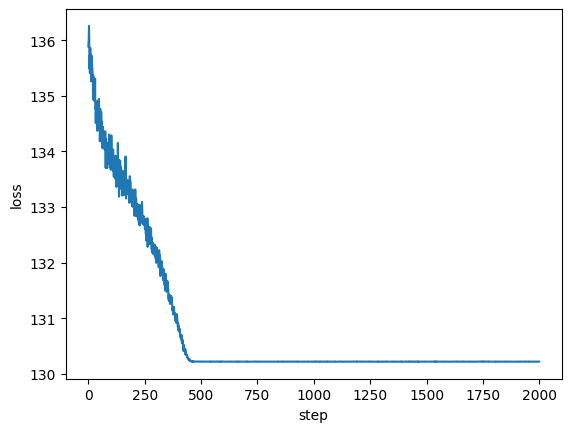

In [ ]:
losses, means, sds, params = svi_inference(
    sensitivity_model, guide, rocksample_stochastic_logs, apply_action_s, num_steps=2000)

print("\n" + "="*50)
print("FINAL SVI POSTERIOR PARAMETERS")
print("="*50)
for key, value in params.items():
    print(f"{key}: {float(value):.6f}")
print("="*50)

plt.plot(losses)
plt.xlabel("step")
plt.ylabel("loss")
plt.show()

In [ ]:
def plot_svi_convergence_rock(losses, means, actual_value=None,
                              param_label=r"$\theta_{\text{sensitivity}}$"):
    loss_arr = np.asarray(losses, dtype=float)
    mean_arr = np.asarray(means,  dtype=float)

    # Professional styling
    plt.style.use('default')
    fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(8, 6))

    # Top: ELBO with BLACK styling
    ax0.plot(loss_arr, color="black", lw=1.5, alpha=0.8)
    ax0.set_title("SVI Loss Convergence (ELBO)", fontsize=13, pad=15)
    ax0.set_xlabel("Iteration", fontsize=11)
    ax0.set_ylabel("Loss", fontsize=11)
    ax0.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax0.spines['top'].set_visible(False)
    ax0.spines['right'].set_visible(False)

    # Bottom: mean trace
    ax1.plot(mean_arr, color="steelblue", lw=2, alpha=0.9, label="SVI posterior mean")

    if actual_value is not None:
        ax1.axhline(float(actual_value), color="red", linestyle="-", lw=2.5, alpha=0.9,
                    label=f"Simulation value: {actual_value}")

    # Position text just above final mean value
    if len(mean_arr) > 0:
        final_mean = mean_arr[-1]
        final_iteration = len(mean_arr) - 1

        # Calculate offset as 3% of the y-range
        y_range = ax1.get_ylim()[1] - ax1.get_ylim()[0]
        y_offset = y_range * 0.03

        ax1.text(final_iteration, final_mean + y_offset,
                f'Final SVI: {final_mean:.3f}',
                ha='right', va='bottom', fontsize=9, alpha=0.7)

    ax1.set_title(f"Parameter Convergence: {param_label}", fontsize=13, pad=15)
    ax1.set_xlabel("Iteration", fontsize=11)
    ax1.set_ylabel("Posterior mean", fontsize=11)
    ax1.legend(loc="best", framealpha=0.95, fontsize=10)
    ax1.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()
    return fig, (ax0, ax1)


def plot_posterior_histogram_rock(final_params, means, actual_value=None,
                                 param_label=r"$\theta_{\text{sensitivity}}$", num_samples=40000,
                                 map_estimates=None, pg_samples=None):
    # Extract SVI posterior parameters (Gamma via mean/variance)
    mean_svi = float(np.asarray(final_params["sensi_mean"]))
    var_svi = float(np.asarray(final_params["sensi_vari"]))

    if mean_svi <= 0 or var_svi <= 0:
        raise ValueError(f"Invalid SVI moments for Gamma: mean={mean_svi}, var={var_svi}")

    # Convert to Gamma shape/scale parameters
    k_svi = (mean_svi * mean_svi) / var_svi  # shape
    theta_svi = var_svi / mean_svi          # scale
    svi_samples = np.random.gamma(shape=k_svi, scale=theta_svi, size=int(num_samples))

    # Professional styling
    plt.style.use('default')
    fig, ax = plt.subplots(figsize=(8, 5))

    # Create x-axis for density curves based on 99.5% credible interval
    svi_ci_995 = np.percentile(svi_samples, [0.25, 99.75])
    ci_range = svi_ci_995[1] - svi_ci_995[0]
    x_min = max(0, svi_ci_995[0] - 0.3 * ci_range)
    x_max = svi_ci_995[1] + 0.3 * ci_range

    # Adjust x-axis if PG samples provided
    if pg_samples is not None:
        pg_samples = np.array(pg_samples)
        pg_ci_995 = np.percentile(pg_samples, [0.25, 99.75])
        x_min = max(0, min(x_min, pg_ci_995[0] - 0.3 * (pg_ci_995[1] - pg_ci_995[0])))
        x_max = max(x_max, pg_ci_995[1] + 0.3 * (pg_ci_995[1] - pg_ci_995[0]))

    x = np.linspace(x_min, x_max, 200)

    # Compute and plot SVI density (smooth curve)
    svi_kde = stats.gaussian_kde(svi_samples)
    svi_density = svi_kde(x)
    ax.fill_between(x, svi_density, alpha=0.3, color='steelblue', label='SVI posterior')
    ax.plot(x, svi_density, color='steelblue', linewidth=2)

    # Add PG posterior as HISTOGRAM if provided (shows particle degeneracy)
    if pg_samples is not None:
        # Use 40 bins to show degeneracy clearly
        ax.hist(pg_samples, bins=40, alpha=0.3, color='orange',
                density=True, label='PG posterior', edgecolor='darkorange', linewidth=0.5)

        # PG statistics
        pg_mean = np.mean(pg_samples)
        pg_ci = np.percentile(pg_samples, [2.5, 97.5])
        ax.axvline(pg_mean, color='orange', linestyle='--', linewidth=2,
                   alpha=0.9, label=f'PG mean: {pg_mean:.3f}')

    # Add SVI vertical lines and credible intervals
    svi_mean = float(means[-1])
    svi_ci = np.percentile(svi_samples, [2.5, 97.5])

    ax.axvline(svi_mean, color='steelblue', linestyle='--', linewidth=2,
               alpha=0.8, label=f'SVI mean: {svi_mean:.3f}')
    ax.axvspan(svi_ci[0], svi_ci[1], alpha=0.1, color='steelblue',
            label=f'95% CI: [{svi_ci[0]:.2f}, {svi_ci[1]:.2f}]')

    # Add MAP estimates if provided
    if map_estimates is not None:
        map_estimates = np.array(map_estimates)
        map_mean = np.mean(map_estimates)

        # Plot individual MAP estimates as thin vertical lines
        for i, estimate in enumerate(map_estimates):
            if i == 0:
                ax.axvline(estimate, color='green', linestyle='-', linewidth=1,
                          alpha=0.5, label='MAP estimates')
            else:
                ax.axvline(estimate, color='green', linestyle='-', linewidth=1,
                          alpha=0.5)

        # Plot MAP mean as thicker line
        ax.axvline(map_mean, color='green', linestyle='--', linewidth=2,
                   alpha=0.9, label=f'MAP mean: {map_mean:.3f}')

    # Add simulation value line
    if actual_value is not None:
        ax.axvline(float(actual_value), color='red', linestyle='-', linewidth=2.5,
                   alpha=0.9, label=f'Simulation value: {actual_value}')

    # Professional styling
    ax.set_xlabel(param_label, fontsize=12)
    ax.set_ylabel('Posterior density', fontsize=12)
    ax.set_title(f'Posterior Inference Results: {param_label}', fontsize=13, pad=20)
    ax.legend(loc='best', fontsize=10, framealpha=0.95)
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Set axis limits with padding
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, None)

    plt.tight_layout()
    plt.show()

    # Enhanced numerical summary
    print("\n" + "="*60)
    print("POSTERIOR INFERENCE SUMMARY")
    print("="*60)
    print(f"{'Method':<12} {'Mean':<8} {'Std':<8} {'95% CI':<20}")
    print("-" * 60)

    # SVI statistics
    print(f"{'SVI':<12} {svi_mean:<8.3f} {np.std(svi_samples):<8.3f} "
          f"[{svi_ci[0]:.3f}, {svi_ci[1]:.3f}]")

    # PG statistics if provided
    if pg_samples is not None:
        pg_mean = np.mean(pg_samples)
        pg_std = np.std(pg_samples)
        pg_ci = np.percentile(pg_samples, [2.5, 97.5])
        print(f"{'PG':<12} {pg_mean:<8.3f} {pg_std:<8.3f} "
              f"[{pg_ci[0]:.3f}, {pg_ci[1]:.3f}]")

    # MAP statistics if provided
    if map_estimates is not None:
        map_estimates = np.array(map_estimates)
        map_mean = np.mean(map_estimates)
        map_std = np.std(map_estimates)
        map_ci = np.percentile(map_estimates, [2.5, 97.5])
        print(f"{'MAP':<12} {map_mean:<8.3f} {map_std:<8.3f} "
              f"[{map_ci[0]:.3f}, {map_ci[1]:.3f}]")

    if actual_value is not None:
        true_val = float(actual_value)
        svi_error = abs(svi_mean - true_val)
        print(f"\nValue in Simulations Comparison:")
        print(f"  Simulation value: {true_val:.3f}")
        print(f"  SVI error:  {svi_error:.4f}")

        if pg_samples is not None:
            pg_error = abs(pg_mean - true_val)
            print(f"  PG error:   {pg_error:.4f}")

        if map_estimates is not None:
            map_error = abs(map_mean - true_val)
            print(f"  MAP error:  {map_error:.4f}")

    print("="*60)

    return fig, ax

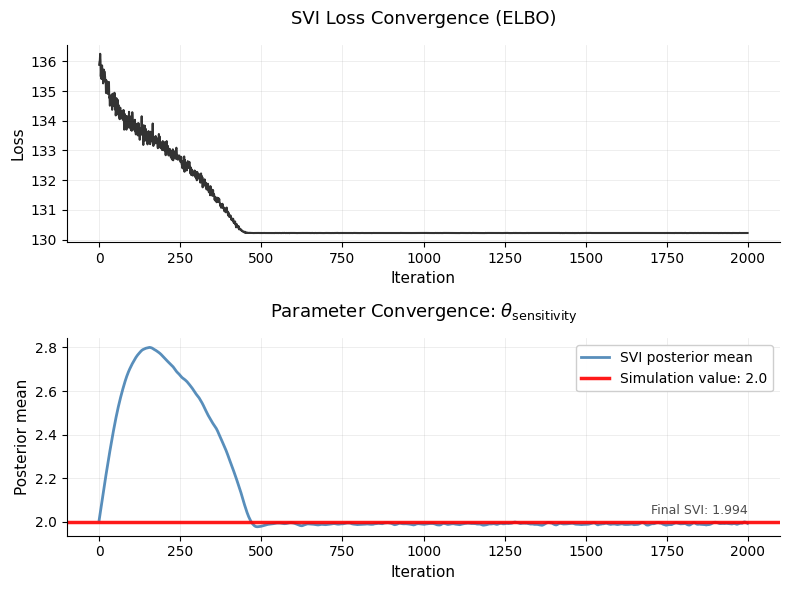

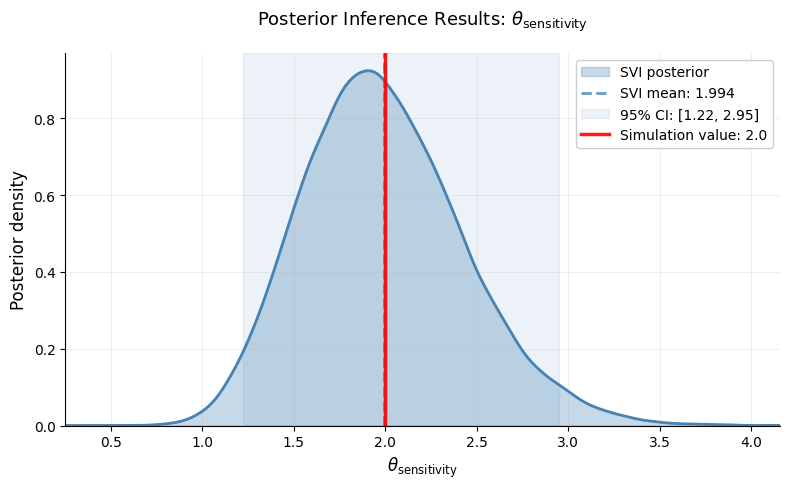


POSTERIOR INFERENCE SUMMARY
Method       Mean     Std      95% CI              
------------------------------------------------------------
SVI          1.994    0.439    [1.225, 2.947]

Value in Simulations Comparison:
  Simulation value: 2.000
  SVI error:  0.0065


(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Posterior Inference Results: $\\theta_{\\text{sensitivity}}$'}, xlabel='$\\theta_{\\text{sensitivity}}$', ylabel='Posterior density'>)

In [ ]:
plot_svi_convergence_rock(
    losses, means,
    actual_value=2.0,
    param_label=r"$\theta_{\text{sensitivity}}$")

plot_posterior_histogram_rock(
    params, means,
    actual_value=2.0,
    param_label=r"$\theta_{\text{sensitivity}}$")

In [ ]:
actual_trajectories = []
for episode in rocksample_stochastic_logs:
    episode_trajectory = []

    # Add initial position
    if episode[0].a is None:
        x, y = episode[0].p
    episode_trajectory.append((x, y))

    # Add positions from movement actions
    for step in episode:
        if step.a in ['up', 'down', 'right', 'left']:
            episode_trajectory.append(step.p)

    actual_trajectories.append(episode_trajectory)

nuts_kernel = NUTS(sensitivity_model, step_size=0.1)
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=10000, num_chains=2)
rng_key = jax.random.PRNGKey(int(time.time() * 1E6))
mcmc.run(rng_key, 2, rocksample_stochastic_logs, actual_trajectories)

mcmc_samples = mcmc.get_samples()
mcmc_sensitivity_samples = mcmc_samples['sensi']

mcmc.print_summary()

/tmp/ipython-input-1460534111.py:18: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=10000, num_chains=2)
sample: 100%|██████████| 11000/11000 [00:40<00:00, 269.44it/s, 3 steps of size 9.58e-01. acc. prob=0.94]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
     sensi      2.04      0.44      2.01      1.33      2.76   7847.59      1.00

Number of divergences: 0


In [ ]:
def plot_mcmc_posterior(mcmc, actual_value=2.0, param_label=r"$\theta_{\text{sensitivity}}$"):
    """
    Plot MCMC posterior histogram.
    """
    mcmc_samples = np.array(mcmc.get_samples()['sensi'])

    plt.style.use('default')
    fig, ax = plt.subplots(figsize=(8, 5))

    # Histogram
    ax.hist(mcmc_samples, bins='auto', density=True, alpha=0.6, color='steelblue',
            label='MCMC posterior')

    # Add mean line
    mcmc_mean = np.mean(mcmc_samples)
    ax.axvline(mcmc_mean, color='steelblue', linestyle='--', linewidth=2,
               label=f'MCMC mean: {mcmc_mean:.3f}')

    # Add simulation value
    if actual_value is not None:
        ax.axvline(float(actual_value), color='red', linestyle='-', linewidth=2,
                   label=f'Simulation value: {actual_value}')

    ax.set_xlabel(param_label, fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title('MCMC Posterior (Known Positions)', fontsize=13)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print summary
    print(f"MCMC mean: {mcmc_mean:.4f}")
    print(f"MCMC std:  {np.std(mcmc_samples):.4f}")

    return fig, ax

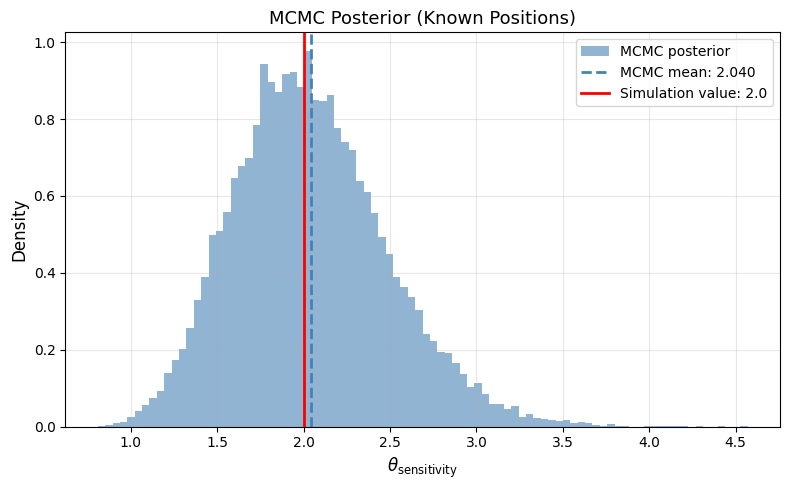

MCMC mean: 2.0405
MCMC std:  0.4437


(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'MCMC Posterior (Known Positions)'}, xlabel='$\\theta_{\\text{sensitivity}}$', ylabel='Density'>)

In [ ]:
plot_mcmc_posterior(mcmc, actual_value=2.0)

## Baselines

We compare our SVI approach to two baseline methods:

1. **EM (Expectation-Maximization)**: Gives a single point estimate but doesn't capture uncertainty
2. **Particle Gibbs**: The "gold standard" MCMC method that gives the full posterior distribution

Why we need these baselines:
- EM shows what you get with a simple optimization approach
- Particle Gibbs is the exact method - it's our ground truth to compare against
- We want to show that SVI gives similar results to Particle Gibbs but runs much faster than EM with multiple restarts

The key insight: While EM can find good point estimates, it doesn't tell us how uncertain we are about the parameters. This uncertainty is crucial for real robot deployments where we need to balance exploration and exploitation.

## EM Algorithm

We use EM with a trick: sample many possible trajectories, then keep only the top K most likely ones for each episode. This is like "best guess" inference - we're finding the single best parameter value that explains the data.

The algorithm:
1. **E-step**: Given current parameter, compute weights for sampled trajectories
2. **M-step**: Given weighted trajectories, find new parameter via MAP estimation (includes prior)
3. Repeat until convergence

We run this multiple times with different random initializations to see how stable the estimates are. If we get different answers each time, that tells us there's uncertainty - but EM itself doesn't give us that uncertainty directly.

In [ ]:
def sample_trajectories(log, apply_action, n_samples=100):
    trajectories = []
    for _ in range(n_samples):
        trajectory = []
        if log[0].a is None:
            x, y = log[0].p
        trajectory.append((x, y))

        for e in log:
            if e.a in ['up', 'down', 'right', 'left']:
                x, y = apply_action(e.a, x, y)
                trajectory.append((x, y))

        trajectories.append(trajectory)
    return trajectories

def compute_trajectory_weights(log, trajectories, sensitivity):
    log_ws = []
    for traj in trajectories:
        lp = logprob_sensitivity(sensitivity, NROCKS, 0, log, traj)
        log_ws.append(float(lp))
    log_ws = np.asarray(log_ws, dtype=np.float64)

    if not np.isfinite(log_ws).any():
        return np.ones_like(log_ws) / len(log_ws)

    m = np.max(log_ws)
    ws = np.exp(log_ws - m)
    s = ws.sum()
    if s <= 1e-300:
        return np.ones_like(ws) / len(ws)
    else:
        w = ws / s
        return w / w.sum()

def select_multiple_trajectories(trajectories, weights, k=5):
    """Select top K trajectories based on weights"""
    top_indices = np.argsort(weights)[-k:]
    selected_trajs = [trajectories[i] for i in top_indices]
    selected_weights = weights[top_indices]
    selected_weights = selected_weights / selected_weights.sum()
    return selected_trajs, selected_weights

def em_algorithm(logs, apply_action, n_samples=20, max_iterations=20, k_trajectories=5, show_prints=True):
    sensitivity = np.random.uniform(1.0, 5.0)
    history = [sensitivity]
    iter_times = []  # Track per-iteration times

    if show_prints:
        print(f"EM with MAP: sampling {n_samples} trajectories, using top {k_trajectories} per episode")

    all_trajectories = [sample_trajectories(log, apply_action, n_samples) for log in logs]

    converged = False

    for iteration in range(max_iterations):
        iter_start = time.time()  # Start timing this iteration

        if show_prints:
            print(f"\nIteration {iteration + 1}: sensitivity = {sensitivity:.4f}")

        all_weights = [compute_trajectory_weights(log, trajs, sensitivity)
                      for log, trajs in zip(logs, all_trajectories)]

        selected_trajectories = []
        selected_weights = []
        for trajs, weights in zip(all_trajectories, all_weights):
            sel_trajs, sel_weights = select_multiple_trajectories(trajs, weights, k_trajectories)
            selected_trajectories.append(sel_trajs)
            selected_weights.append(sel_weights)

        def neg_log_likelihood(sens):
            if sens <= 0.01:
                return 1e10

            total = 0.0
            for log, trajs, weights in zip(logs, selected_trajectories, selected_weights):
                episode_ll = 0.0
                for traj, weight in zip(trajs, weights):
                    episode_ll += weight * logprob_sensitivity(sens, NROCKS, 0, log, traj)
                total += episode_ll

            prior_ll = jnp.log(0.2) - 0.2 * sens
            return -(total + prior_ll)

        result = minimize_scalar(neg_log_likelihood, bounds=(sensitivity*0.5, sensitivity*2), method='bounded')
        new_sensitivity = result.x

        iter_times.append(time.time() - iter_start)  # Record iteration time

        if show_prints:
            print(f"  New sensitivity: {new_sensitivity:.4f}")
            print(f"  Change: {abs(new_sensitivity - sensitivity):.6f}")

        if abs(new_sensitivity - sensitivity) < 1e-4:
            print(f"  Converged after {iteration + 1} iterations")
            converged = True
            break

        sensitivity = new_sensitivity
        history.append(sensitivity)

    if not converged:
        print("  Did not converge.")

    print(f"last value: {history[-1]:.4f}")
    return history, iter_times, converged

print("EM functions loaded")

EM functions loaded


EM with MAP: sampling 20 trajectories, using top 1 per episode

Iteration 1: sensitivity = 4.7006
  New sensitivity: 2.3503
  Change: 2.350299

Iteration 2: sensitivity = 2.3503
  New sensitivity: 2.1455
  Change: 0.204832

Iteration 3: sensitivity = 2.1455
  New sensitivity: 2.1436
  Change: 0.001863

Iteration 4: sensitivity = 2.1436
  New sensitivity: 2.1454
  Change: 0.001752

Iteration 5: sensitivity = 2.1454
  New sensitivity: 2.1436
  Change: 0.001750

Iteration 6: sensitivity = 2.1436
  New sensitivity: 2.1443
  Change: 0.000640

Iteration 7: sensitivity = 2.1443
  New sensitivity: 2.1437
  Change: 0.000582

Iteration 8: sensitivity = 2.1437
  New sensitivity: 2.1463
  Change: 0.002585

Iteration 9: sensitivity = 2.1463
  New sensitivity: 2.1444
  Change: 0.001923

Iteration 10: sensitivity = 2.1444
  New sensitivity: 2.1444
  Change: 0.000089
  Converged after 10 iterations
last value: 2.1444

Results:
MAP:  2.1444


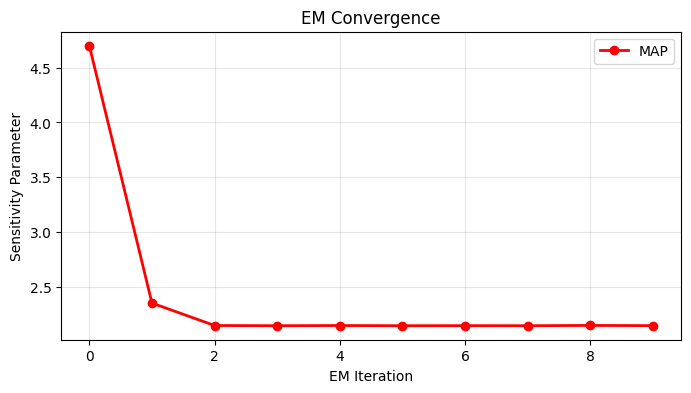

In [ ]:
map_history, _, _ = em_algorithm(rocksample_stochastic_logs, apply_action_s, k_trajectories=1)

print(f"\nResults:")
print(f"MAP:  {map_history[-1]:.4f}")

# Plot
plt.figure(figsize=(8, 4))
plt.plot(map_history, 'r-o', label='MAP', linewidth=2)
plt.xlabel('EM Iteration')
plt.ylabel('Sensitivity Parameter')
plt.title('EM Convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
N_EM_RUNS = 10

if file_exists('em_results', subdir='experiments'):
    em_data = load_data('em_results', subdir='experiments')
    map_estimates = em_data['map_estimates']
    em_iter_times = em_data['em_iter_times']
    print(f"Loaded {len(map_estimates)} EM runs")
else:
    print(f"Running EM {N_EM_RUNS} times...")
    map_estimates = []
    em_iter_times = []
    iteration = 0

    while iteration < N_EM_RUNS:
        print(f"Run {iteration+1}/{N_EM_RUNS}")
        history, iter_times, converged = em_algorithm(rocksample_stochastic_logs, apply_action_s, k_trajectories=1, show_prints=False)
        if not converged:
            continue

        iteration += 1
        map_estimates.append(history[-1])
        em_iter_times.append(iter_times)

    em_data = {
        'map_estimates': map_estimates,
        'em_iter_times': em_iter_times,
        'n_runs': N_EM_RUNS,
        'k_trajectories': 1
    }
    save_data('em_results', em_data, subdir='experiments')

map_estimates = np.array(map_estimates)

# Calculate statistics
total_runtimes = [np.sum(times) for times in em_iter_times]
n_iterations = [len(times) for times in em_iter_times]
per_iter_times = [np.mean(times) for times in em_iter_times]

print(f"\nEM Results:")
print(f"  MAP estimate: mean={np.mean(map_estimates):.4f}, std={np.std(map_estimates):.4f}")
print(f"  Total runtime: mean={np.mean(total_runtimes):.1f}s, std={np.std(total_runtimes):.1f}s")
print(f"  Iterations: mean={np.mean(n_iterations):.1f}, std={np.std(n_iterations):.1f}")
print(f"  Per iteration: mean={np.mean(per_iter_times):.3f}s, std={np.std(per_iter_times):.3f}s")

em_results does not exist
Running EM 10 times...
Run 1/10
  Did not converge.
last value: 1.9723
Run 1/10
  Converged after 7 iterations
last value: 2.1215
Run 2/10
  Converged after 4 iterations
last value: 1.9718
Run 3/10
  Converged after 9 iterations
last value: 2.0758
Run 4/10
  Converged after 5 iterations
last value: 2.0587
Run 5/10
  Did not converge.
last value: 2.0684
Run 5/10
  Converged after 4 iterations
last value: 2.1358
Run 6/10
  Converged after 4 iterations
last value: 2.1416
Run 7/10
  Converged after 20 iterations
last value: 2.0687
Run 8/10
  Converged after 3 iterations
last value: 2.1076
Run 9/10
  Converged after 9 iterations
last value: 2.1249
Run 10/10
  Did not converge.
last value: 2.0367
Run 10/10
  Did not converge.
last value: 1.9796
Run 10/10
  Converged after 13 iterations
last value: 2.0800
Saved: em_results

EM Results:
  MAP estimate: mean=2.0887, std=0.0479
  Total runtime: mean=70.8s, std=46.9s
  Iterations: mean=7.8, std=5.0
  Per iteration: mean=

## Particle Gibbs

Particle Gibbs is a MCMC method that gives us the full posterior distribution. It's the "correct" way to do Bayesian inference but it's expensive - we need thousands of particles and many iterations.

How it works:
1. Sample many particles (possible trajectories + parameter values)
2. Weight them by how well they explain the observations
3. Resample and repeat, keeping one "retained" trajectory for stability
4. After many iterations, collect all the parameter samples

This gives us the true posterior distribution that we can compare our SVI results against. It's slow but accurate.

In [ ]:
def csmc(particles, retained=None):
    """Conditional SMC"""
    steps = [[] for _ in particles]

    while not particles[0].done:
        for particle in particles:
            particle.step()
        if retained is not None:
            particles[0] = retained.pop(0)
        for i in range(len(particles)):
            steps[i].append(copy(particles[i]))
        indices = np.random.choice(
            len(particles), size=len(particles),
            p=softmax([particle.log_prob for particle in particles]))
        particles = [particles[i].renew() for i in indices]

    for particle in particles:
        assert particle.done, "not all particles terminated at the same time"

    retained = steps[random.randint(0, len(steps) - 1)]
    return particles, retained


def pgibbs(mkparticle, nparticles, niter, collect=None):
    """Particle MCMC (Gibbs) loop with per-iteration timing"""
    retained = None
    iter_times = []

    for iter in tqdm.trange(niter):
        iter_start = time.time()

        particles = [mkparticle() for _ in range(nparticles)]
        particles, retained = csmc(particles, retained)

        if collect is not None:
            collect(particles)

        iter_times.append(time.time() - iter_start)

    return particles, iter_times


class Particle():
    def __init__(self, log_prob=0):
        self.log_prob = log_prob
        self.done = False

    def step(self):
        pass

    def renew(self):
        particle = copy(self)
        particle.log_prob = 0
        return particle


class RockSampleParticle(Particle):
    def __init__(self, move, height, nrocks, logs, log_prob=0):
        super().__init__(log_prob)

        self.move = move
        self.height = height
        self.nrocks = nrocks
        self.logs = [[]] + logs
        self.sensi = expon(scale=5).rvs()

    def step(self):
        log, logs = self.logs[0], self.logs[1:]
        if not log:
            self.logs = self.logs[1:]
            log, logs = self.logs[0], self.logs[1:]

            self.x = 0
            self.y = random.randint(0, self.height - 1)
            self.rocks = stats.bernoulli(p=0.5).rvs(size=self.nrocks)

        entry, log = log[0], log[1:]
        if not log and not logs:
            self.done = True
        self.logs = [log] + logs

        match entry.a:
            case 'right' | 'up' | 'down' | 'left':
                self.x, self.y = self.move(entry.a, self.x, self.y)
            case 'sense' | 'sample':
                irock, (xrock, yrock) = entry.r
                if entry.a == 'sense':
                    dx, dy = self.x - xrock, self.y - yrock
                    p = 0.5 + 0.5 * np.exp(
                        -(np.sqrt(dx * dx + dy * dy) * np.log(2)) / self.sensi)
                    p = np.clip(p, 0.01, 0.99)
                else:
                    p = 0.99
                if self.rocks[irock] == entry.o:
                    self.log_prob += np.log(p)
                else:
                    self.log_prob += np.log(1 - p)

print("Particle Gibbs functions loaded")

Particle Gibbs functions loaded


In [ ]:
NPARTICLES = 1000
NITER = 100

if file_exists('pg_results', subdir='experiments'):
    pg_data = load_data('pg_results', subdir='experiments')
    sensis = np.array(pg_data['samples'])
    pg_time = pg_data.get('runtime', None)
    iter_times = pg_data.get('iter_times', None)
    print(f"Loaded {len(sensis)} Particle Gibbs samples")
    if pg_time:
        print(f"Runtime: {pg_time:.2f} seconds")
else:
    print(f"Running Particle Gibbs ({NPARTICLES} particles, {NITER} iterations)...")

    start_time = time.time()

    apply_action_fn = lambda a, x, y: apply_action_s(a, x, y, prob_success=PSUCCESS)
    mkparticle = lambda: RockSampleParticle(apply_action_fn, HEIGHT, NROCKS, rocksample_stochastic_logs)

    sensis = []
    def collect(particles):
        global sensis
        sensis.extend([p.sensi for p in particles])

    particles, iter_times = pgibbs(mkparticle, NPARTICLES, niter=NITER, collect=collect)

    sensis = np.array(sensis)
    pg_time = time.time() - start_time

    pg_data = {
        'samples': sensis.tolist(),
        'runtime': pg_time,
        'iter_times': iter_times,
        'nparticles': NPARTICLES,
        'niter': NITER
    }
    save_data('pg_results', pg_data, subdir='experiments')
    print(f"Completed in {pg_time:.2f} seconds")

print(f"\nParticle Gibbs Results: mean={np.mean(sensis):.4f}, std={np.std(sensis):.4f}")
print(f"Runtime: {pg_time:.2f}s (mean per iter: {np.mean(iter_times):.2f}s)")

pg_results exists
Loaded: pg_results
Loaded 100000 Particle Gibbs samples
Runtime: 2096.84 seconds

Particle Gibbs Results: mean=1.8845, std=0.5909
Runtime: 2096.84s (mean per iter: 20.97s)


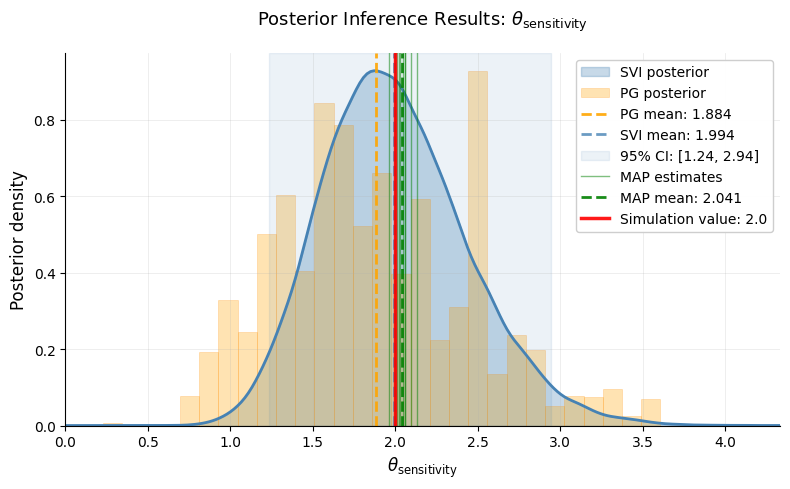


POSTERIOR INFERENCE SUMMARY
Method       Mean     Std      95% CI              
------------------------------------------------------------
SVI          1.994    0.438    [1.235, 2.944]
PG           1.884    0.591    [0.887, 3.178]
MAP          2.041    0.045    [1.971, 2.122]

Value in Simulations Comparison:
  Simulation value: 2.000
  SVI error:  0.0065
  PG error:   0.1155
  MAP error:  0.0409


(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Posterior Inference Results: $\\theta_{\\text{sensitivity}}$'}, xlabel='$\\theta_{\\text{sensitivity}}$', ylabel='Posterior density'>)

In [ ]:
plot_posterior_histogram_rock(
    params,
    means,
    actual_value=2.0,
    map_estimates=map_estimates,
    pg_samples=sensis
)

In [ ]:
# METHOD COMPARISON - ROCKSAMPLE
print("\n" + "="*80)
print("METHOD COMPARISON - ROCKSAMPLE")
print("="*80)

true_value = 2.0

# MCMC
mcmc_mean = np.mean(mcmc_sensitivity_samples)
mcmc_ci = np.percentile(mcmc_sensitivity_samples, [2.5, 97.5])

# SVI
svi_mean = float(params['sensi_mean'])
svi_var = float(params['sensi_vari'])
svi_error = abs(svi_mean - true_value)

k_svi = (svi_mean ** 2) / svi_var
theta_svi = svi_var / svi_mean
svi_samples = np.random.gamma(shape=k_svi, scale=theta_svi, size=10000)
svi_ci = np.percentile(svi_samples, [2.5, 97.5])
w_dist_svi = wasserstein_distance(mcmc_sensitivity_samples, svi_samples)

# EM
em_mean = np.mean(map_estimates)
em_error = abs(em_mean - true_value)

# PG
pg_mean = np.mean(sensis)
pg_error = abs(pg_mean - true_value)
pg_ci = np.percentile(sensis, [2.5, 97.5])
w_dist_pg = wasserstein_distance(mcmc_sensitivity_samples, sensis)

# Print summary
print(f"{'Method':<12} {'Mean':<10} {'Error':<10} {'W-Distance':<12} {'95% CI':<25}")
print("-" * 85)
print(f"{'True Value':<12} {true_value:<10.2f} {'-':<10} {'-':<12} {'-':<25}")
print(f"{'MCMC':<12} {mcmc_mean:<10.2f} {'-':<10} {'-':<12} [{mcmc_ci[0]:.2f}, {mcmc_ci[1]:.2f}]")
print(f"{'SVI':<12} {svi_mean:<10.2f} {svi_error:<10.3f} {w_dist_svi:<12.3f} [{svi_ci[0]:.2f}, {svi_ci[1]:.2f}]")
print(f"{'EM':<12} {em_mean:<10.2f} {em_error:<10.3f} {'N/A':<12} {'N/A':<25}")
print(f"{'PG':<12} {pg_mean:<10.2f} {pg_error:<10.3f} {w_dist_pg:<12.3f} [{pg_ci[0]:.2f}, {pg_ci[1]:.2f}]")
print("="*80)


METHOD COMPARISON - ROCKSAMPLE
Method       Mean       Error      W-Distance   95% CI                   
-------------------------------------------------------------------------------------
True Value   2.00       -          -            -                        
MCMC         2.04       -          -            [1.27, 3.00]
SVI          1.99       0.006      0.046        [1.23, 2.94]
EM           2.04       0.041      N/A          N/A                      
PG           1.88       0.116      0.191        [0.89, 3.18]
